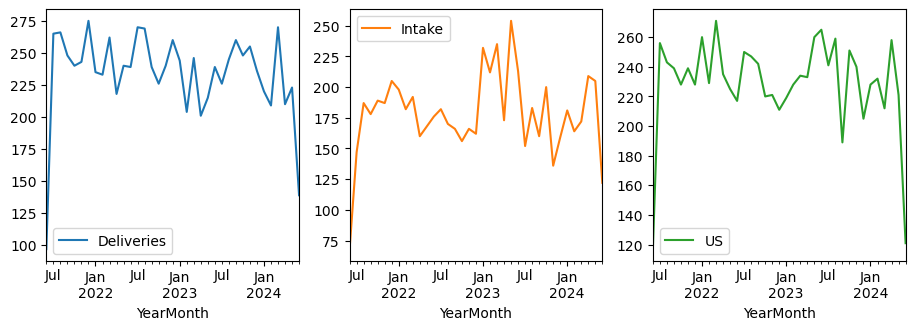

In [2]:
#Read CombinedDate.csv and plot each column against the first column which is date / time in YYYY-MM Format
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

df = pd.read_csv('CombinedData.csv')
df['YearMonth'] = pd.to_datetime(df['YearMonth'])
df.set_index('YearMonth', inplace=True)
df.plot(subplots=True, layout=(4,4), figsize=(15, 15), sharex=False)
plt.show()


407.98710328444383


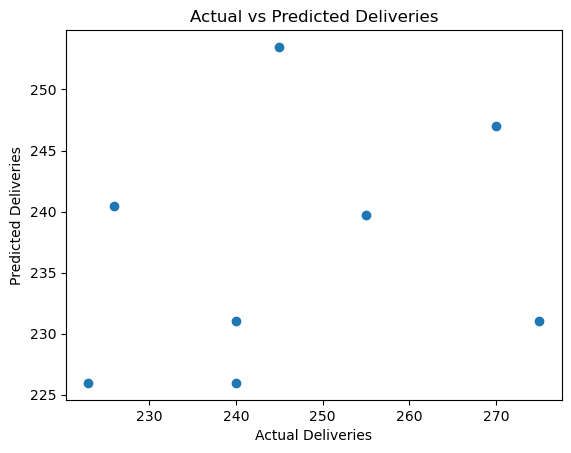

[4.25864190e-04 7.24470588e-01]
65.77342938505959
Index(['Intake', 'US'], dtype='object')


In [3]:
#Build a regressions model to predict Deliveries based on the other columns, ignoring date/time
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error

X = df.drop('Deliveries', axis=1)
y = df['Deliveries']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
model = LinearRegression()

model.fit(X_train, y_train)
y_pred = model.predict(X_test)
print(mean_squared_error(y_test, y_pred))

#Plot the actual vs predicted deliveries
plt.scatter(y_test, y_pred)
plt.xlabel('Actual Deliveries')
plt.ylabel('Predicted Deliveries')
plt.title('Actual vs Predicted Deliveries')
plt.show()

#Print the model coefficients
print(model.coef_)
print(model.intercept_)
print(X.columns)



In [7]:
#Create an enhanced dataset with the "lagged" signals as new columns, going back to two lags 

df_lagged = df.copy()
df_lagged['Deliveries_lag_1'] = df_lagged['Deliveries'].shift(1)
df_lagged['Deliveries_lag_2'] = df_lagged['Deliveries'].shift(2)

df_lagged['Intake_lag_1'] = df_lagged['Intake'].shift(1)
df_lagged['Intake_lag_2'] = df_lagged['Intake'].shift(2)

df_lagged['US_lag_1'] = df_lagged['US'].shift(1)
df_lagged['US_lag_2'] = df_lagged['US'].shift(2)

df_lagged = df_lagged.dropna()
df_lagged.head()

,Deliveries,Intake,US,Deliveries_lag_1,Deliveries_lag_2,Intake_lag_1,Intake_lag_2,US_lag_1,US_lag_2
YearMonth,,,,,,,,,
2021-08-01,266,187,243,265.0,97.0,147.0,68.0,256.0,117.0
2021-09-01,248,178,239,266.0,265.0,187.0,147.0,243.0,256.0
2021-10-01,240,189,228,248.0,266.0,178.0,187.0,239.0,243.0
2021-11-01,243,187,239,240.0,248.0,189.0,178.0,228.0,239.0
2021-12-01,275,205,228,243.0,240.0,187.0,189.0,239.0,228.0


712.5825149538442


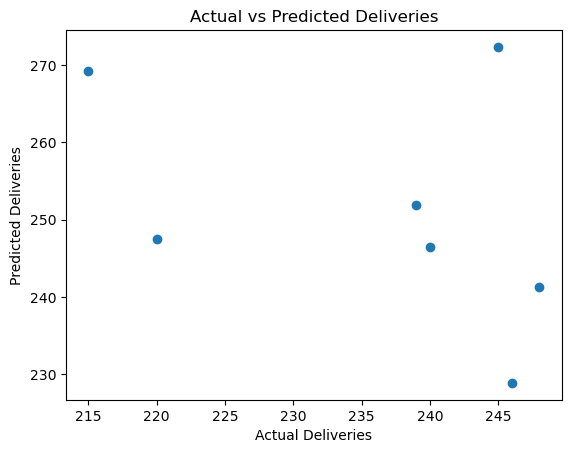

[ 0.1312651   0.51020869 -0.21160613  0.08057529 -0.5638933  -0.15246165
  0.43373756  0.00365764]
157.40053779810845
Index(['Intake', 'US', 'Deliveries_lag_1', 'Deliveries_lag_2', 'Intake_lag_1',
       'Intake_lag_2', 'US_lag_1', 'US_lag_2'],
      dtype='object')


In [8]:
#build a regression model with the lagged signals
X = df_lagged.drop('Deliveries', axis=1)
y = df_lagged['Deliveries']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
model = LinearRegression()

model.fit(X_train, y_train)
y_pred = model.predict(X_test)
print(mean_squared_error(y_test, y_pred))

#Plot the actual vs predicted deliveries
plt.scatter(y_test, y_pred)
plt.xlabel('Actual Deliveries')
plt.ylabel('Predicted Deliveries')
plt.title('Actual vs Predicted Deliveries')
plt.show()

#Print the model coefficients
print(model.coef_)
print(model.intercept_)
print(X.columns)
